# MES Pullback-to-MA, long-only, 15-minute bars (Tradovate exchange)

A structurally different entry style from every strategy tested so far in this
pipeline. Donchian, Keltner, and SuperTrend all enter *at* a new price extreme
(breakout/flip logic) -- bought at the most expensive point of the swing, and
profitable only if the trend keeps extending from there. This strategy instead
buys weakness within an established uptrend: it waits for price to pull back to
a faster moving average and reclaim it, entering mid-trend at a discount rather
than chasing strength.

**Mechanism** (`PullbackToMaStrategy`): a slow MA defines the trend regime
(close above it permits longs), a fast MA is the pullback level being defended.
Entry fires the bar price closes back above the fast MA having closed at/below
it the previous bar (the reclaim). Stop-loss sits at the fast MA, offset by
an ATR buffer (the fast MA, unlike a breakout channel edge, can sit arbitrarily
close to price, so it needs the buffer to avoid a near-zero risk distance).
Take-profit is a fixed R:R multiple of that stop distance.

Same discipline as every other notebook in this pipeline: naive full-history
grid -> best-combo detailed report -> 75/25 holdout -> (if promising)
walk-forward, on real Databento MES 1-minute data resampled to 15-minute bars.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import PullbackToMaStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 168278  span: 2019-05-05 22:14:59.999000 -> 2026-07-12 23:14:59.999000


## Grid search: slow (trend) EMA length x fast (pullback) EMA length, direction=long

`atr_length=10`, `stop_atr_mult=1.0`, `risk_reward_ratio=2.0` fixed for this
first pass (same fixed-extras-while-gridding-the-core-two-parameters convention
as the Donchian/Keltner notebooks). Both EMAs precomputed once per candidate
pair, fed to `PullbackToMaStrategy` as a dumb consumer.


In [3]:
TREND_MA_CANDIDATES = [100, 150, 200, 300]
PULLBACK_MA_CANDIDATES = [10, 20, 30, 50]
ATR_LENGTH = 10
STOP_ATR_MULT = 1.0
RISK_REWARD_RATIO = 2.0
DEPOSIT_USD = 50_000


def run_pullback_backtest(ohlc_slice: pd.DataFrame, trend_ma_length: int, pullback_ma_length: int, key: str,
                           direction: StrategyDirection = StrategyDirection.long):
    trend_ma = Indicators.ema(ohlc_slice, length=trend_ma_length)
    pullback_ma = Indicators.ema(ohlc_slice, length=pullback_ma_length)
    atr = Indicators.atr(ohlc_slice, length=ATR_LENGTH)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="trend_ma", df=trend_ma)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="pullback_ma", df=pullback_ma)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="atr", df=atr)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=PullbackToMaStrategy(
            key=key, market=market, symbol=SYMBOL, trend_ma_key="trend_ma", pullback_ma_key="pullback_ma", atr_key="atr",
            stop_atr_mult=STOP_ATR_MULT, risk_reward_ratio=RISK_REWARD_RATIO, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for trend_ma_length in TREND_MA_CANDIDATES:
    for pullback_ma_length in PULLBACK_MA_CANDIDATES:
        bt, drawdown_mw = run_pullback_backtest(ohlc, trend_ma_length, pullback_ma_length,
                                                  key=f"PB_long_{trend_ma_length}_{pullback_ma_length}")
        summary = bt.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        grid_backtests[(trend_ma_length, pullback_ma_length)] = (bt, drawdown_mw)
        grid_rows.append({
            "trend_ma_length": trend_ma_length, "pullback_ma_length": pullback_ma_length,
            "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
        })
    print(f"trend_ma_length={trend_ma_length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(f"\ngrid done in {time.time() - _t0:.0f}s\n")
print(grid_results.to_string())


trend_ma_length=100 done, 90s elapsed


trend_ma_length=150 done, 182s elapsed


trend_ma_length=200 done, 276s elapsed


trend_ma_length=300 done, 376s elapsed



grid done in 376s

    trend_ma_length  pullback_ma_length  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0               100                  50           -2.598335     -0.015862              -12.9353         2306.0            320.3         34.952298       1.115497               0.048569              1.044282           2.760867         7748.65           False
1               200                  50           -2.272432     -0.020091              -20.0784         2150.0            298.6         33.906977       1.128098               0.017209              1.051329           2.967411         7599.41           False
2               150                  50           -3.741473     -0.046446              -17.4366         2134.0            296.4         34.348641       1.119447               0.030459              1.043341    

### Heatmaps: Sharpe ratio and net return across (trend_ma_length, pullback_ma_length)


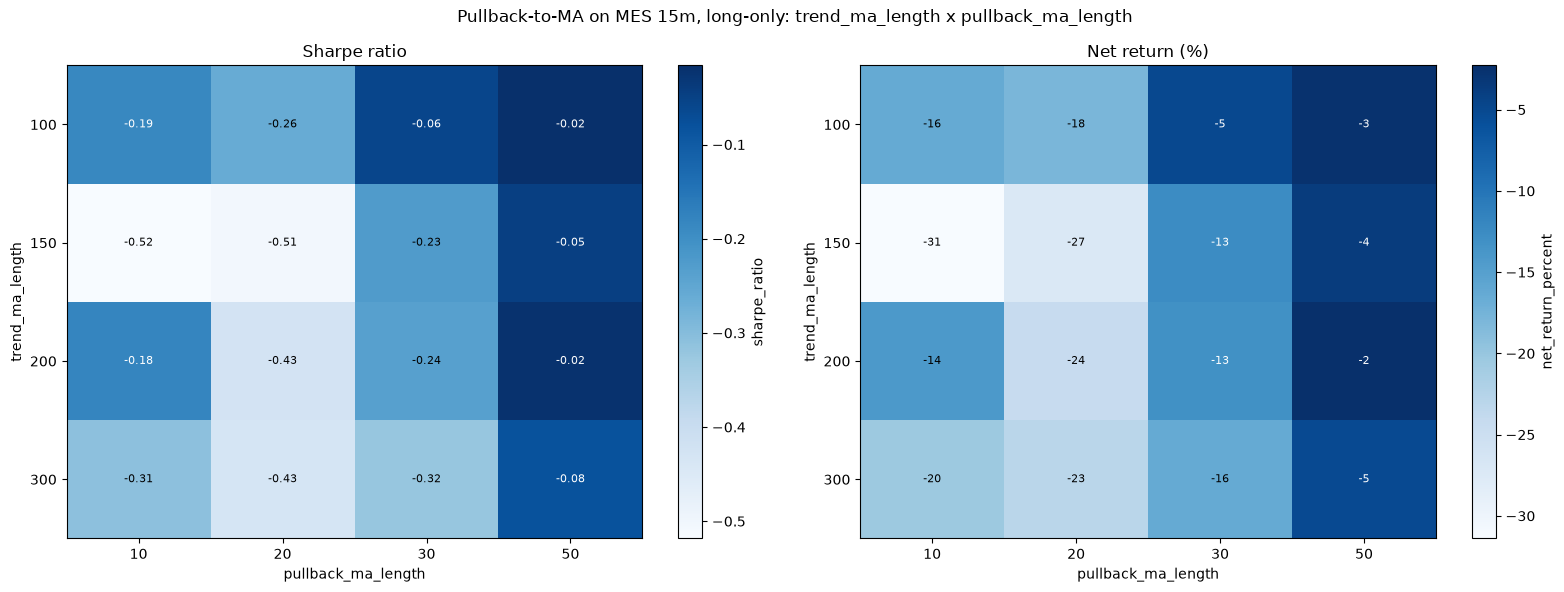

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("pullback_ma_length")
    ax.set_ylabel("trend_ma_length")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="trend_ma_length", columns="pullback_ma_length", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="trend_ma_length", columns="pullback_ma_length", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("Pullback-to-MA on MES 15m, long-only: trend_ma_length x pullback_ma_length")
fig.tight_layout()
plt.show()


## Detailed report for the best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (trend_ma_length, pullback_ma_length) combo from the grid above.


Best combo: trend_ma_length=100, pullback_ma_length=50
Candles Processed: 168277
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,-0.0159,-0.4430,0.2531,-1.5920,0.9335,-0.2596,0.1563,-0.5002,0.0771,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-0.0232,-0.5841,0.3761,-1.9822,1.5918,-0.3610,0.2156,-0.6453,0.1064,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,5.7019,4.8223,8.4783,3.9735,8.3807,4.7239,2.9265,4.5841,4.0425,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-0.3654,-3.2099,2.6309,-8.8835,11.4654,-1.9239,0.6043,-3.4227,0.3362,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.0282,-0.5746,0.2389,-0.8569,2.6136,-0.2207,0.2298,-0.3589,0.0740,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.2009,-0.3799,0.2389,-0.8546,2.6060,-0.2201,0.2298,-0.3579,0.0389,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-12.9353,-5.5866,-11.0106,-10.3675,-4.3868,-8.7155,-2.6292,-9.5366,-4.5425,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,1278,238,117,358,117,354,190,359,132,719,How long it took to recover the loss. Shorter is better.
ulcer_index,6.3081,3.5025,2.6574,5.5845,1.7070,6.0812,1.3597,5.7568,2.0588,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.5395,-0.4841,-0.7703,-0.4006,-0.7890,-0.5393,-0.3177,-0.4705,-0.4543,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


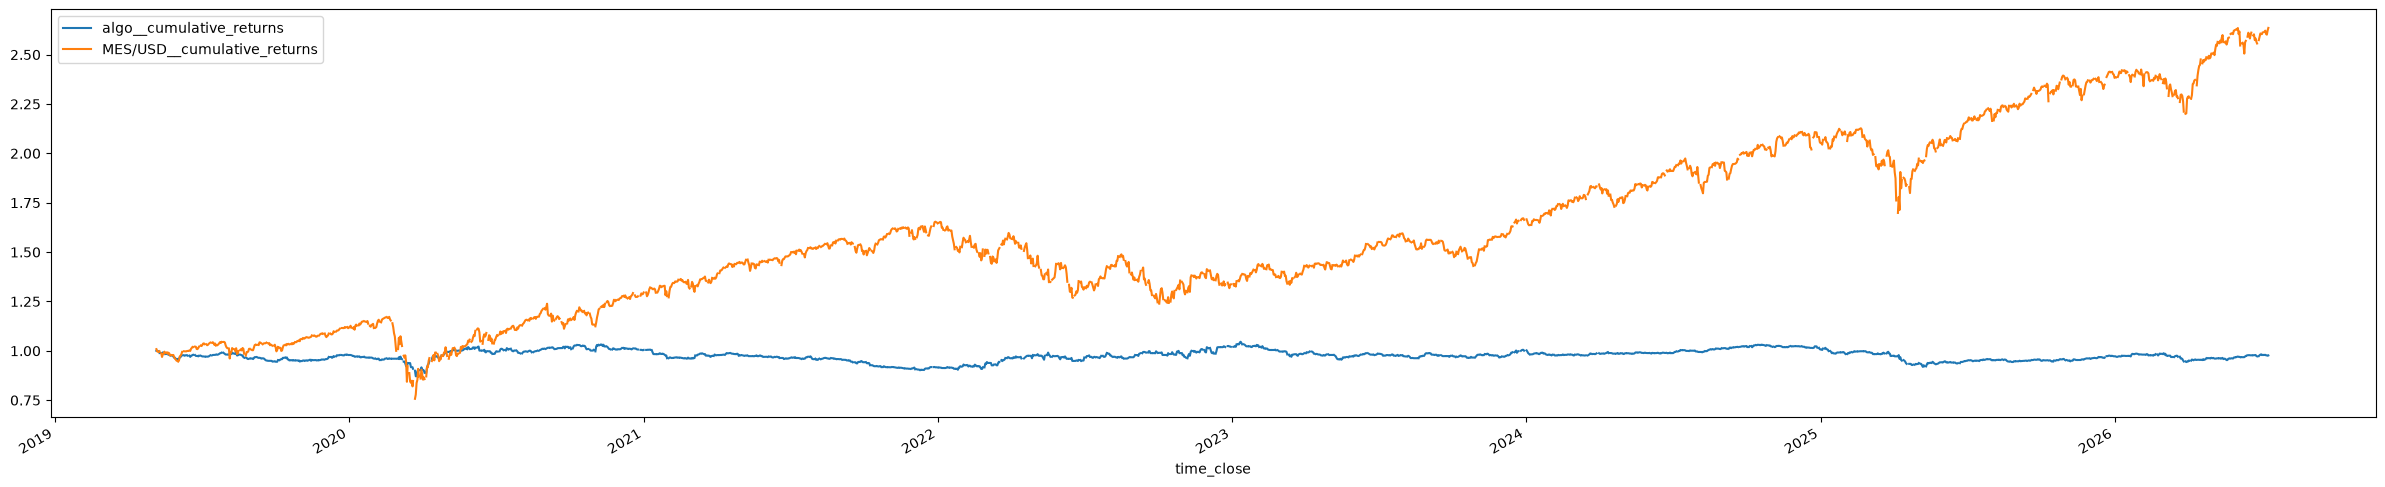

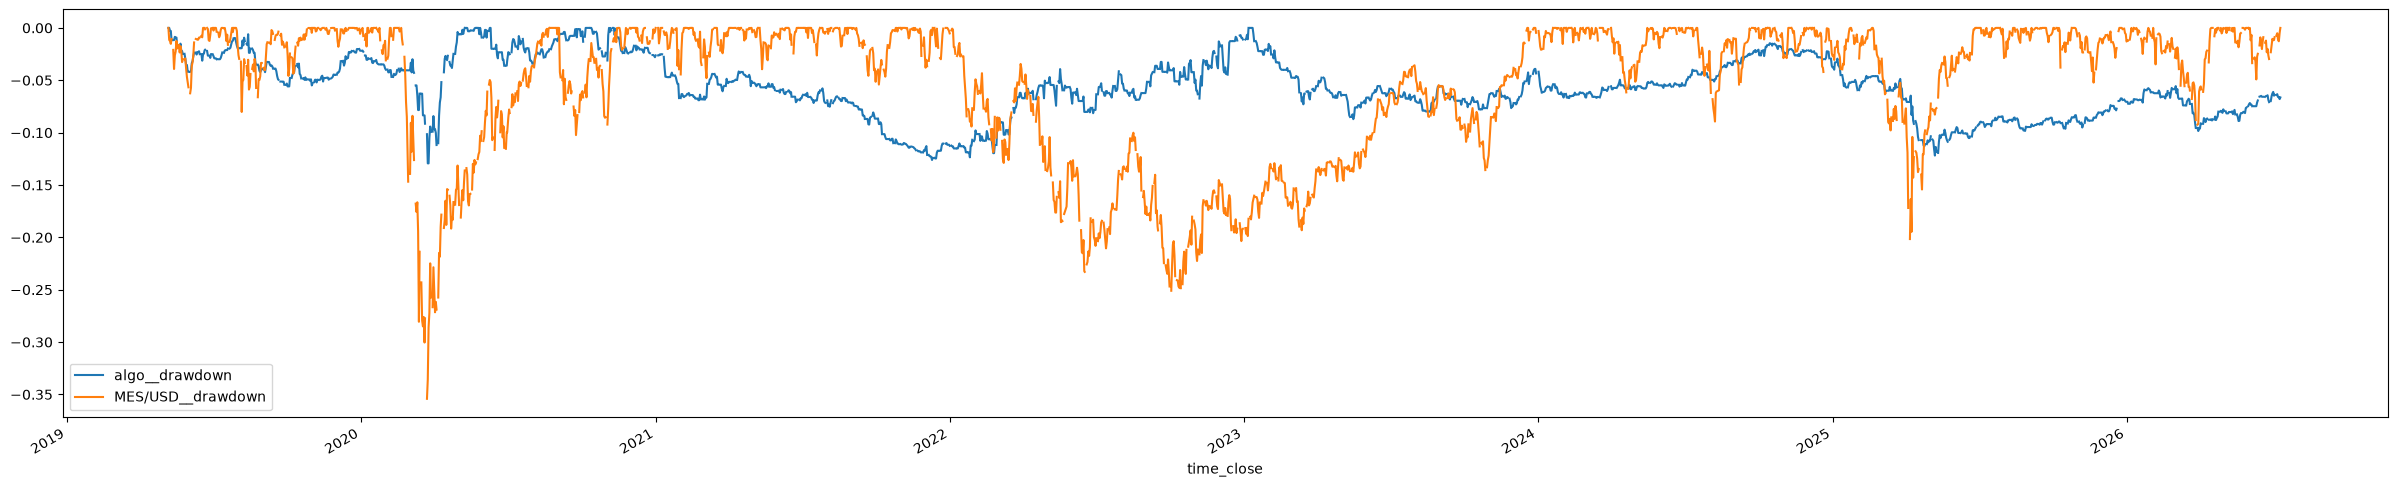

In [5]:
best_trend_ma_length, best_pullback_ma_length = grid_results.iloc[0][["trend_ma_length", "pullback_ma_length"]]
best_trend_ma_length = int(best_trend_ma_length)
best_pullback_ma_length = int(best_pullback_ma_length)
print(f"Best combo: trend_ma_length={best_trend_ma_length}, pullback_ma_length={best_pullback_ma_length}")
best_backtest, best_drawdown_mw = grid_backtests[(best_trend_ma_length, best_pullback_ma_length)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Holdout check: does the best combo survive a train/test split?


In [6]:
split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_pullback_backtest(ohlc_slice, best_trend_ma_length, best_pullback_ma_length, key=f"PB_holdout_{label}")
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


train/test split at 2024-09-24 02:44:59.999000  (126208 train bars, 42070 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                       2306         34.952298      0.035734         0.001467       -0.015862           -2.598335              1.044282           2.760867              -12.9353           False
TRAIN (75%)                1772         35.101580      0.049259         0.010158        0.072100            2.006677              1.066254           4.334545              -12.9353           False
TEST (last 25%, unseen)     555         34.054054     -0.018997        -0.088830       -0.558346           -6.427185              0.922562          -3.996516              -12.0755           False


## Findings

**Negative from the very first pass -- unlike every other strategy in this
pipeline, this one never even produced a positive full-history grid.**
Donchian, Keltner, and SuperTrend all showed a clean gradient with a solidly
positive top end before holdout was even run; here, **all 16 grid combos are
net-negative** (Sharpe -0.016 to -1.35), and `dollar_profit_factor` barely
clears 1.0 for the best few.

**Best combo (`trend_ma_length=100, pullback_ma_length=50`)**: FULL net
return -2.6%, Sharpe -0.016, `dollar_profit_factor` 1.044 -- essentially a
coin flip with a thin edge either way, not a real signal.

**The standout problem is trade frequency**: 2,306 trades over 7.2 years
(~320/year) for the *best* combo, 3+ times Donchian's/Keltner's typical rate
and rising past 500/year for the shorter pullback MAs. This is the same
failure signature as the original 5-minute/both-direction SuperTrend pass
(see `supertrend-flip-mes-negative.md`): a reclaim-of-a-fast-MA condition on
15-minute bars fires very often on ordinary noise around the average, not
just on genuine "pulled back, now resuming" setups -- the per-trade economics
get diluted by a large number of low-conviction entries.

**Holdout on the best combo**: TRAIN `trade_sharpe_lb`=+0.0102 (barely
positive, the weakest "positive" TRAIN result in this program), TEST
`trade_sharpe_lb`=-0.089 (clearly negative), TEST net_return -6.4%, TEST
`dollar_profit_factor`=0.923 (below 1 -- losing money before even counting
fees more heavily). This doesn't reach the "promising, not yet confirmed"
tier every other strategy hit before walk-forward -- it's negative at every
stage tested so far.

**Bottom line**: pullback-to-MA, as implemented (bare fast-MA reclaim, no
minimum pullback depth or trend-strength confirmation), does not show a real
edge on MES 15m long-only. This is a different failure mode from the
breakout/flip strategies' "promising holdout, failed walk-forward" pattern --
this one fails to even clear the bar for a promising single-split holdout, so
walk-forward isn't warranted here. Not pursuing MNQ/M2K for this exact
implementation without a mechanism change first -- a stronger reclaim filter
(e.g. requiring the pullback to actually touch/dip through the fast MA by a
minimum ATR-scaled depth, or gating entries on ADX to avoid trading reclaims
during genuinely choppy/non-trending stretches) would be the natural next
iteration if this mechanism is worth revisiting, rather than more grid search
on the current bare-reclaim signal.